# MAT 557E HOMEWORK 

## Problem I Definition

### English

This study investigates the one-dimensional heat equation:

$$
u_t = k\,u_{xx}, \quad 0 < x < L,\; t > 0
$$

where $u(x,t)$ represents the temperature and $k$ is the diffusion coefficient.

The problem is considered with the following boundary conditions:

- **Dirichlet:** $u(0,t)=0,\; u(L,t)=0$
- **Neumann:** $u_x(0,t)=0,\; u_x(L,t)=0$

The initial condition is given as:

$$
u(x,0)=f(x)
$$

The equation is solved numerically using the FTCS method and compared with the exact solution.

---

### Türkçe

Bu çalışmada tek boyutlu ısı denklemi incelenmektedir:

$$
u_t = k\,u_{xx}, \quad 0 < x < L,\; t > 0
$$

Burada $u(x,t)$ sıcaklık dağılımını, $k$ ise difüzyon katsayısını temsil eder.

Problem aşağıdaki sınır koşulları ile ele alınır:

- **Dirichlet:** $u(0,t)=0,\; u(L,t)=0$
- **Neumann:** $u_x(0,t)=0,\; u_x(L,t)=0$

Başlangıç koşulu:

$$
u(x,0)=f(x)
$$

Denklem FTCS yöntemi ile sayısal olarak çözülmekte ve analitik çözüm ile karşılaştırılmaktadır.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
#  EXACT SOLUTIONS AND PARAMETERS HEAT
# ==================================================

# Physical parameters
k = 1.0        # diffusion coefficient
L = 1.0        # length of the rod
T = 0.3        # final time

# Numerical parameters
Nx = 45
dx = L / Nx

dt = 0.0002
Nt = int(T / dt)

r = k * dt / dx**2

print("dx =", dx)
print("dt =", dt)
print("Nt =", Nt)
print("r  =", r)

if r > 0.5:
    raise ValueError("Stability condition violated: r must be <= 0.5")

# Spatial grid
x = np.linspace(0, L, Nx + 1)

# Times that we want to save
save_times = [0.0, 0.1, 0.2, 0.3]

# --------------------------------------------------
# Exact solution for Dirichlet BC
# PDE: u_t = k u_xx
# IC : u(x,0) = sin(pi x)
# BC : u(0,t)=0, u(1,t)=0
# Exact solution:
# u(x,t) = exp(-k*pi^2*t) * sin(pi*x)
# --------------------------------------------------
def exact_dirichlet(x, t, k=1.0):
    return np.exp(-k * np.pi**2 * t) * np.sin(np.pi * x)

# --------------------------------------------------
# Exact solution for Neumann BC
# PDE: u_t = k u_xx
# IC : u(x,0) = cos(pi x)
# BC : u_x(0,t)=0, u_x(1,t)=0
# Exact solution:
# u(x,t) = exp(-k*pi^2*t) * cos(pi*x)
# --------------------------------------------------
def exact_neumann(x, t, k=1.0):
    return np.exp(-k * np.pi**2 * t) * np.cos(np.pi * x)

dx = 0.022222222222222223
dt = 0.0002
Nt = 1499
r  = 0.405


In [4]:
# ==============================
#  Heat equation - Dirichlet BC
# ==============================

u = np.sin(np.pi * x)
u[0], u[-1] = 0.0, 0.0     # U[-1] Sonuncu endex

saved_dir = {0.0: u.copy()}

for n in range(1, Nt + 1):
    t = n * dt
    u_new = u.copy()

    # İç noktaları vektörel güncelle
    u_new[1:Nx] = u[1:Nx] + r * (u[2:Nx+1] - 2*u[1:Nx] + u[0:Nx-1])

    # Dirichlet sınır şartı
    u_new[0], u_new[-1] = 0.0, 0.0

    u = u_new

    for ts in save_times:
        if ts not in saved_dir and abs(t - ts) < dt/2:
            saved_dir[ts] = u.copy()

if 0.3 not in saved_dir:
    saved_dir[0.3] = u.copy()
u_dir_final = u.copy()    

In [5]:
# ==============================
# Heat equation - Neumann BC
# ==============================

u = np.cos(np.pi * x)
saved_neu = {0.0: u.copy()}

for n in range(1, Nt + 1):
    t = n * dt
    u_new = u.copy()

    # İç noktalar
    u_new[1:Nx] = u[1:Nx] + r * (u[2:Nx+1] - 2*u[1:Nx] + u[0:Nx-1])

    # Neumann BC: ux = 0
    u_new[0]  = u[0]  + 2*r*(u[1]  - u[0])
    u_new[-1] = u[-1] + 2*r*(u[-2] - u[-1])

    u = u_new.copy()

    for ts in save_times:
        if ts not in saved_neu and abs(t - ts) < dt/2:
            saved_neu[ts] = u.copy()

if 0.3 not in saved_neu:
    saved_neu[0.3] = u.copy()

u_neu_final = u.copy()

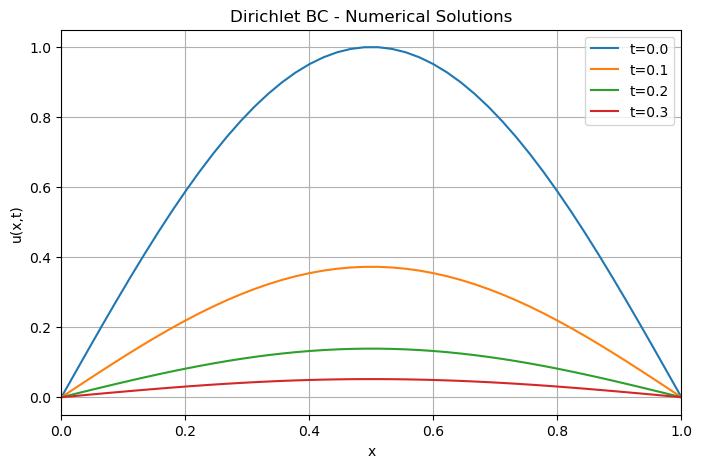

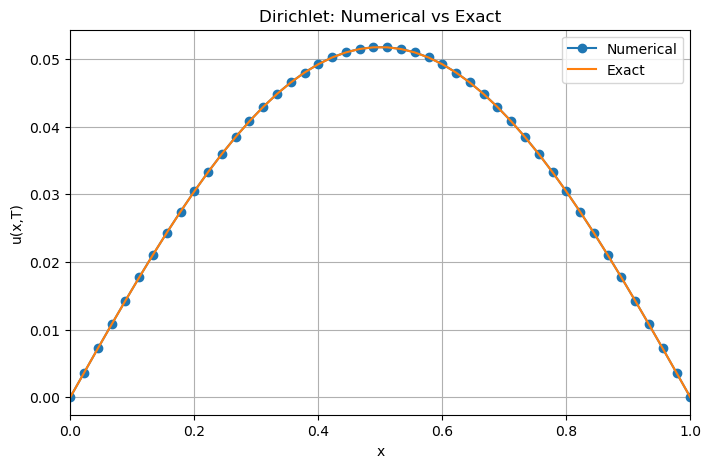

Dirichlet max error = 1.3128961358493951e-05


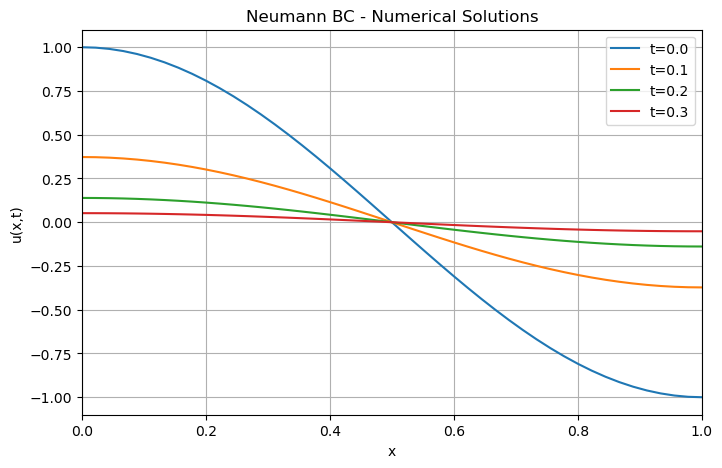

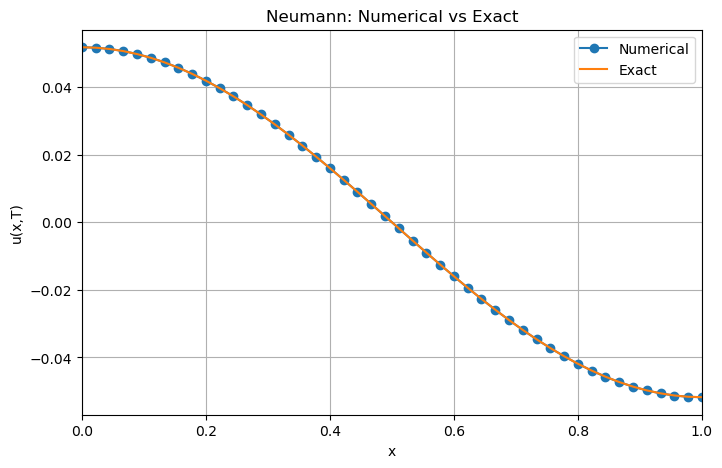

Neumann max error = 1.3136964042058386e-05


In [6]:
# =========================================
#  PLOTS
# =========================================

# ==============================
# 1) Dirichlet numerical solutions
# ==============================
plt.figure(figsize=(8, 5))
for ts in save_times:
    if ts in saved_dir:
        plt.plot(x, saved_dir[ts], label=f"t={ts}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Dirichlet BC - Numerical Solutions")
plt.legend()
plt.grid(True)
plt.xlim(0, 1)
plt.show()


# ==============================
# 2) Dirichlet: Numerical vs Exact
# ==============================
u_dir_exact = exact_dirichlet(x, T, k)
plt.figure(figsize=(8, 5))
plt.plot(x, u_dir_final, 'o-', label="Numerical")
plt.plot(x, u_dir_exact, '-', label="Exact")
plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.title("Dirichlet: Numerical vs Exact")
plt.legend()
plt.grid(True)
plt.xlim(0, 1)
plt.show()

error_dir = np.max(np.abs(u_dir_final - u_dir_exact))
print("Dirichlet max error =", error_dir)


# ==============================
# 3) Neumann numerical solutions
# ==============================
plt.figure(figsize=(8, 5))

for ts in save_times:
    if ts in saved_neu:
        plt.plot(x, saved_neu[ts], label=f"t={ts}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Neumann BC - Numerical Solutions")
plt.legend()
plt.grid(True)
plt.xlim(0, 1)
plt.show()


# ==============================
# 4) Neumann: Numerical vs Exact
# ==============================
u_neu_exact = exact_neumann(x, T, k)

plt.figure(figsize=(8, 5))
plt.plot(x, u_neu_final, 'o-', label="Numerical")
plt.plot(x, u_neu_exact, '-', label="Exact")

plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.title("Neumann: Numerical vs Exact")
plt.legend()
plt.grid(True)
plt.xlim(0, 1)
plt.show()

error_neu = np.max(np.abs(u_neu_final - u_neu_exact))
print("Neumann max error =", error_neu)

## Problem II Definition

### English

This study investigates the one-dimensional wave equation:

$$
u_{tt} = c^2 u_{xx}, \quad 0 < x < L,\; t > 0
$$

where $u(x,t)$ represents the displacement and $c$ is the wave speed.

The problem is considered with the following boundary conditions:

- **Dirichlet:** $u(0,t)=0,\; u(L,t)=0$
- **Neumann:** $u_x(0,t)=0,\; u_x(L,t)=0$

The initial conditions are given as:

$$
u(x,0)=f(x), \qquad u_t(x,0)=g(x)
$$

The equation is solved numerically using the finite difference method and compared with the exact solution.

---

### Türkçe

Bu çalışmada tek boyutlu dalga denklemi incelenmektedir:

$$
u_{tt} = c^2 u_{xx}, \quad 0 < x < L,\; t > 0
$$

Burada $u(x,t)$ yer değiştirmeyi, $c$ ise dalga hızını temsil eder.

Problem aşağıdaki sınır koşulları ile ele alınır:

- **Dirichlet:** $u(0,t)=0,\; u(L,t)=0$
- **Neumann:** $u_x(0,t)=0,\; u_x(L,t)=0$

Başlangıç koşulları şu şekilde verilir:

$$
u(x,0)=f(x), \qquad u_t(x,0)=g(x)
$$

Denklem sonlu farklar yöntemi ile sayısal olarak çözülmekte ve analitik çözüm ile karşılaştırılmaktadır.

In [7]:
# =========================================
#  EXACT SOLUTIONS AND PARAMETERS WAVE
# =========================================

# Physical parameters
c = 2.0      # wave speed
L = 3.0      # length of the domain
T = 0.2    # final time

# Numerical parameters
Nx = 45
dx = L / Nx

dt = 0.02
Nt = int(T / dt)

r = c * dt / dx   # Courant number

print("dx =", dx)
print("dt =", dt)
print("Nt =", Nt)
print("r =", r)

# Stability condition for wave equation
if r > 1:
    raise ValueError("Stability condition violated: r = c*dt/dx must be <= 1")

# Spatial grid
x = np.linspace(0, L, Nx + 1)

# Times that we want to save
save_times = [0.0, 0.1, 0.15, 0.2]

# =========================================
# Exact solution for Dirichlet BC
# PDE: u_tt = c^2 u_xx
# IC:  u(x,0) = sin(pi*x)
#      u_t(x,0) = 0
# BC:  u(0,t)=0, u(L,t)=0
# Exact solution:
# u(x,t) = sin(pi*x) * cos(c*pi*t)
# =========================================
def exact_dirichlet(x, t, c=1.0):
    return np.sin(np.pi * x) * np.cos(c * np.pi * t)

# =========================================
# Exact solution for Neumann BC
# PDE: u_tt = c^2 u_xx
# IC:  u(x,0) = cos(pi*x)
#      u_t(x,0) = 0
# BC:  u_x(0,t)=0, u_x(L,t)=0
# Exact solution:
# u(x,t) = cos(pi*x) * cos(c*pi*t)
# =========================================
def exact_neumann(x, t, c=1.0):
    return np.cos(np.pi * x) * np.cos(c * np.pi * t)

dx = 0.06666666666666667
dt = 0.02
Nt = 10
r = 0.6


In [8]:
# =========================================
#  WAVE EQUATION - DIRICHLET BC
# =========================================

# Başlangıç: u(x,0) = sin(pi*x)
u_old = np.sin(np.pi * x)

# Sınırlar sabit
u_old[0] = 0.0
u_old[-1] = 0.0

# Çözümleri sakla
saved_dir = {0.0: u_old.copy()}

# İlk zaman adımı: u_t(x,0)=0 kullanılıyor
u = u_old.copy()
u[1:Nx] = u_old[1:Nx] + 0.5 * r**2 * (
    u_old[2:Nx+1] - 2*u_old[1:Nx] + u_old[0:Nx-1]
)

# Dirichlet sınır şartı
u[0] = 0.0
u[-1] = 0.0

# Zaman döngüsü
for n in range(1, Nt):
    t = (n + 1) * dt

    u_new = u.copy()

    # İç noktaları güncelle
    u_new[1:Nx] = (
        2*u[1:Nx] - u_old[1:Nx]
        + r**2 * (u[2:Nx+1] - 2*u[1:Nx] + u[0:Nx-1])
    )

    # Dirichlet BC
    u_new[0] = 0.0
    u_new[-1] = 0.0

    # Eski ve yeni seviyeleri kaydır
    u_old = u.copy()
    u = u_new.copy()

    # İstenen zamanları kaydet
    for ts in save_times:
        if ts not in saved_dir and abs(t - ts) < dt/2:
            saved_dir[ts] = u.copy()

# Final çözüm
u_dir_final = u.copy()

In [9]:
# =========================================
#  WAVE EQUATION - NEUMANN BC (CORRECTED)
# =========================================

# Initial condition: u(x,0) = cos(pi*x)
u_old = np.cos(np.pi * x)

# Enforce Neumann BC at t=0
u_old[0] = u_old[1]
u_old[-1] = u_old[-2]

# Store solutions
saved_neu = {0.0: u_old.copy()}

# First time step: u_t(x,0)=0
u = u_old.copy()

# Interior points
u[1:Nx] = (
    u_old[1:Nx]
    + 0.5 * r**2 * (u_old[2:Nx+1] - 2*u_old[1:Nx] + u_old[0:Nx-1])
)

# Boundary points using Neumann BC
u[0] = u_old[0] + r**2 * (u_old[1] - u_old[0])
u[-1] = u_old[-1] + r**2 * (u_old[-2] - u_old[-1])

# Time loop
for n in range(1, Nt):
    t = (n + 1) * dt

    u_new = np.zeros_like(u)

    # Interior points
    u_new[1:Nx] = (
        2*u[1:Nx] - u_old[1:Nx]
        + r**2 * (u[2:Nx+1] - 2*u[1:Nx] + u[0:Nx-1])
    )

    # Left boundary: Neumann BC
    u_new[0] = (
        2*u[0] - u_old[0]
        + 2*r**2 * (u[1] - u[0])
    )

    # Right boundary: Neumann BC
    u_new[-1] = (
        2*u[-1] - u_old[-1]
        + 2*r**2 * (u[-2] - u[-1])
    )

    # Shift time levels
    u_old = u.copy()
    u = u_new.copy()

    # Save selected times
    for ts in save_times:
        if ts not in saved_neu and abs(t - ts) < dt/2:
            saved_neu[ts] = u.copy()

# Final solution
u_neu_final = u.copy()

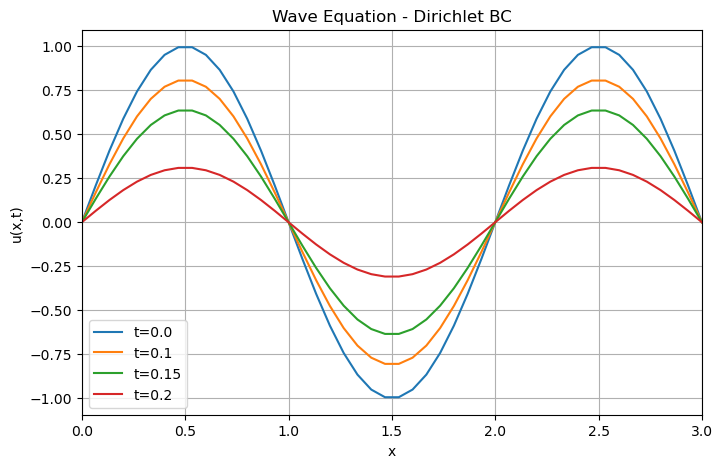

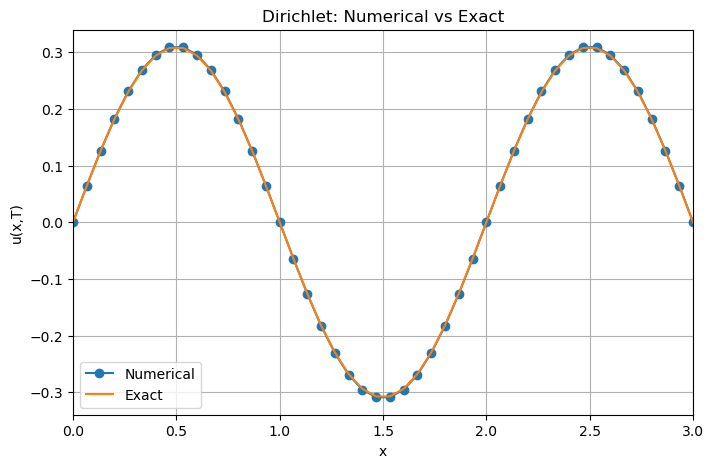

Dirichlet max error = 0.0013916993674762401


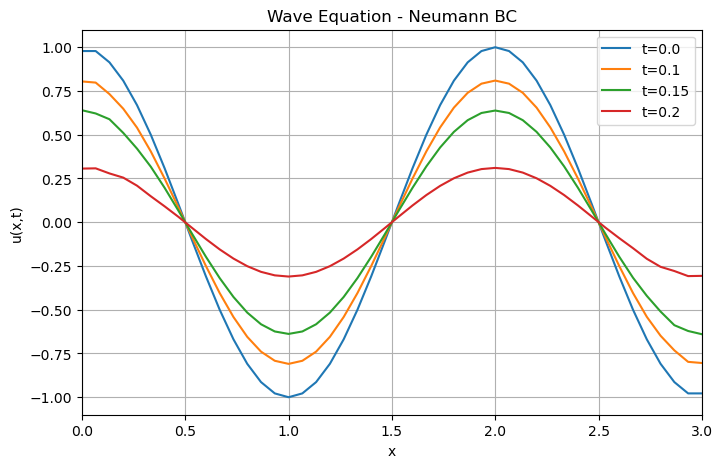

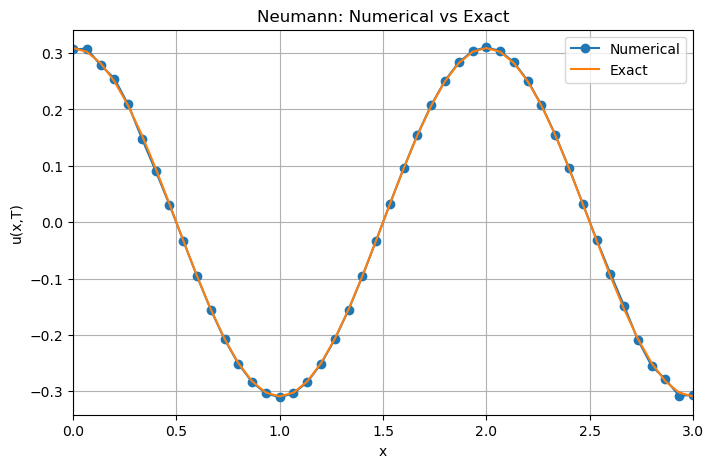

Neumann max error = 0.006132063383527814


In [10]:
# =========================================
#  PLOTS
# =========================================

# 1) Dirichlet numerical solutions
plt.figure(figsize=(8,5))
for ts in save_times:
    if ts in saved_dir:
        plt.plot(x, saved_dir[ts], label=f"t={ts}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Wave Equation - Dirichlet BC")
plt.legend()
plt.grid(True)
plt.xlim(0, 3)
plt.show()


# 2) Dirichlet numerical vs exact
u_dir_exact = exact_dirichlet(x, T, c)

plt.figure(figsize=(8,5))
plt.plot(x, u_dir_final, "o-", label="Numerical")
plt.plot(x, u_dir_exact, "-", label="Exact")

plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.title("Dirichlet: Numerical vs Exact")
plt.legend()
plt.grid(True)
plt.xlim(0, 3)
plt.show()

error_dir = np.max(np.abs(u_dir_final - u_dir_exact))
print("Dirichlet max error =", error_dir)


# 3) Neumann numerical solutions
plt.figure(figsize=(8,5))
for ts in save_times:
    if ts in saved_neu:
        plt.plot(x, saved_neu[ts], label=f"t={ts}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Wave Equation - Neumann BC")
plt.legend()
plt.grid(True)
plt.xlim(0, 3)
plt.show()


# 4) Neumann numerical vs exact
u_neu_exact = exact_neumann(x, T, c)

plt.figure(figsize=(8,5))
plt.plot(x, u_neu_final, "o-", label="Numerical")
plt.plot(x, u_neu_exact, "-", label="Exact")

plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.title("Neumann: Numerical vs Exact")
plt.legend()
plt.grid(True)
plt.xlim(0, 3)
plt.show()

error_neu = np.max(np.abs(u_neu_final - u_neu_exact))
print("Neumann max error =", error_neu)

## Problem III Definition
### English
This study considers the nonlinear partial differential equation where is the unknown function. The problem is studied under both Dirichlet and Neumann boundary conditions, together with a suitable initial condition.

Since the equation is nonlinear, the solution is obtained numerically using a fundamental finite difference scheme. The results are then discussed in terms of qualitative and quantitative behavior.

### Türkçe
Bu çalışmada doğrusal olmayan kısmi diferansiyel denklem incelenmektedir. Burada  bilinmeyen fonksiyondur. Problem, uygun bir başlangıç koşulu ile birlikte hem Dirichlet hem de Neumann sınır koşulları altında ele alınmaktadır.

Denklem doğrusal olmadığından çözüm temel sonlu fark yöntemi ile sayısal olarak elde edilmekte, sonuçlar ise nitel ve nicel olarak değerlendirilmektedir.

In [11]:
# =========================================
#   PARAMETERS
# =========================================

L = 2.0
T = 0.3

Nx = 45
dx = L / Nx

dt = 0.001
Nt = int(T / dt)

x = np.linspace(0, L, Nx + 1)
save_times = [0.0, 0.1, 0.2, 0.3]

print("dx =", dx)
print("dt =", dt)
print("Nt =", Nt)

dx = 0.044444444444444446
dt = 0.001
Nt = 300


In [18]:
# =========================================
#  DIRICHLET BC
# =========================================

u = np.sin(np.pi * x)
u[0] = 0.0
u[-1] = 0.0

saved_dir = {0.0: u.copy()}

for n in range(1, Nt + 1):
    t = n * dt
    u_new = u.copy()

    # interior points
    u_new[1:Nx] = u[1:Nx] + dt * (
        (u[2:Nx+1] - u[1:Nx]) / dx + np.sin(u[1:Nx])
    )

    # Dirichlet BC
    u_new[0] = 0.0
    u_new[-1] = 0.0

    u = u_new.copy()

    for ts in save_times:
        if ts not in saved_dir and abs(t - ts) < dt/2:
            saved_dir[ts] = u.copy()

u_dir_final = u.copy()

In [19]:
# =========================================
# NEUMANN BC
# =========================================

u = np.cos(np.pi * x)

# Initial Neumann BC
u[0]  = u[1]
u[-1] = u[-2]

saved_neu = {0.0: u.copy()}

for n in range(1, Nt + 1):
    t = n * dt
    u_new = u.copy()

    # interior points
    u_new[1:Nx] = u[1:Nx] + dt * (
        (u[2:Nx+1] - u[1:Nx]) / dx + np.sin(u[1:Nx])
    )

    # Neumann BC: ux = 0 at both boundaries
    u_new[0]  = u_new[1]
    u_new[-1] = u_new[-2]

    u = u_new.copy()

    for ts in save_times:
        if ts not in saved_neu and abs(t - ts) < dt/2:
            saved_neu[ts] = u.copy()

u_neu_final = u.copy()

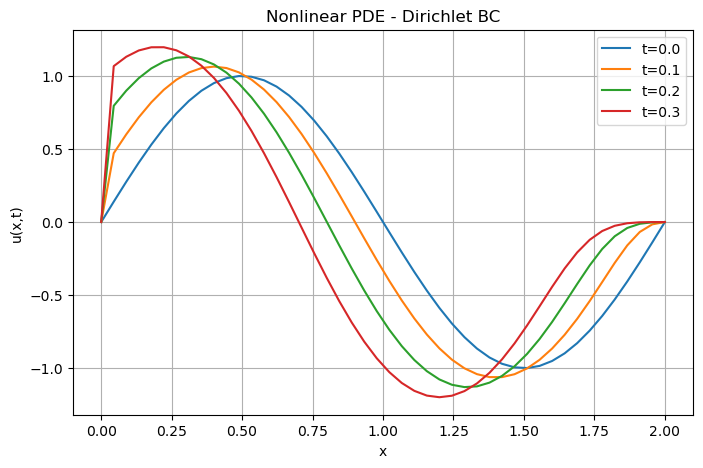

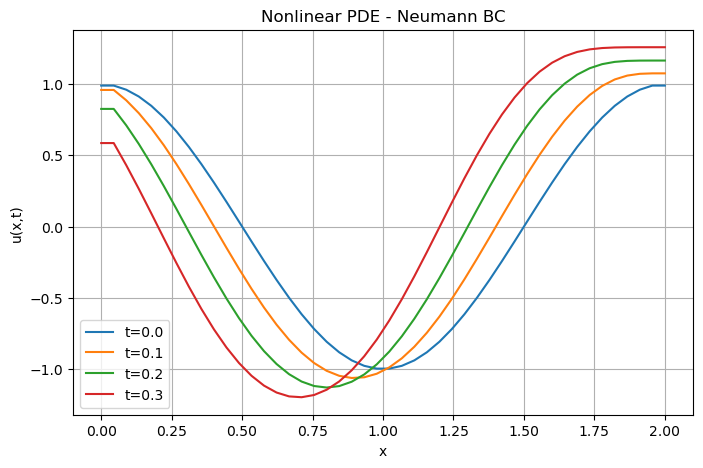

In [20]:
# =========================================
#  PLOTS
# =========================================

# Dirichlet solutions
plt.figure(figsize=(8,5))
for ts in save_times:
    if ts in saved_dir:
        plt.plot(x, saved_dir[ts], label=f"t={ts}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Nonlinear PDE - Dirichlet BC")
plt.legend()
plt.grid(True)
plt.show()

# Neumann solutions
plt.figure(figsize=(8,5))
for ts in save_times:
    if ts in saved_neu:
        plt.plot(x, saved_neu[ts], label=f"t={ts}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Nonlinear PDE - Neumann BC")
plt.legend()
plt.grid(True)
plt.show()

